<a href="https://colab.research.google.com/github/AcSsalazar/the-color-of-emotions/blob/main/Notebooks/3.3-feature-extraction-with-pytorch-2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Generación de Tensores mediante PyTorch y Torchaudio

En este *notebook* se realiza la **extracción de características acústicas** con PyTorch/Torchaudio/nnAudio (sin Librosa), siguiendo una estructura modular análoga al notebook [3.1-feature-extraction-rav-&-crema](https://github.com/AcSsalazar/the-color-of-emotions/blob/main/Notebooks/3.1-feature-extraction-rav-%26-crema.ipynb)

**Pipeline:**
1. Imports y configuración
2. Descarga de datasets + copia a SSD + limpieza de duplicados
3. Parsing de metadatos + split speaker-independent (80/10/10)
4. Preprocesamiento de waveform (resample → trim → normalización → padding)
5. Extracción de features torch: 3 canales — Mel(dB), MFCC(dB), MFCC-Delta.
6. Z-score por muestra y por canal (sin leakage)
7. Data augmentation fijo (solo `surprised` × `train`)
8. Serialización: un `.pt` por split con `x`, `y`, `meta`, `class_to_idx`, `config`
9. Sanity checks finales


## 1. Imports

In [1]:
# Imports
# -------------------------------------------------------
import os
import gc
import random
import logging
import shutil
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
import torch
import torch.nn.functional as F
import torchaudio
import torchaudio.transforms as T
#-------------------------------------------------------
from tqdm import tqdm
# Loggers de progeso y bandera de Runtime
# -------------------------------------------------------
logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)s %(message)s')
logger = logging.getLogger(__name__)
torch.manual_seed(42)
torch.backends.cudnn.benchmark = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


Llevar a cabo la **extracción de características acústicas** mediante **Torchaudio** (PyTorch), permite aprovechar la aceleración por **GPU**. Este tipo de *runtime* es fundamental para optimizar los tiempos de procesamiento en grandes volúmenes de datos.

Ademas, en este caso vamos a extraer caracteristicas diferentes para nuestros tres canales pertenecientes a los tensores, en lugar de usar MFCC, y sus dos derivadas (delta, delta-delta), vamos a usar espectrograma de mel, por su buen rendimiento en pruebas vistas antes con los archivos PNG, su delta de orden uno y el espectrogrma cochlear.

En lugar de utilizar únicamente MFCC y sus derivadas, configuraremos la entrada con:

1. **Espectrograma de Mel:** Debido a su excelente rendimiento demostrado en las pruebas previas con archivos PNG.
2. **Delta (orden uno):** Para capturar la dinámica del espectrograma de Mel.
3. **Espectrograma Coclear:** Para incorporar una representación basada en la percepción auditiva humana.

## 2. Configuración y rutas

Se determinó que el valor más adecuado para la constante `MAX_DURATION` es **1.6 segundos**. Este ajuste surge de la necesidad de estandarizar el tamaño de los espectrogramas basándose en la densidad de la información útil (la voz del actor).

El cálculo se rige por la siguiente relación matemática:

$$MAX\_DURATION = \frac{Target\ Frames \times Hop\ Length}{Sample\ Rate}$$

Sustituyendo los valores definidos para este experimento:

$$\frac{50 \times 512}{16,000} = 1.6\ s$$

**Justificación del ajuste:**
En la versión anterior del pipeline, donde `MAX_DURATION = 3.0 s`, se obtenía una resolución temporal de aproximadamente 94 frames. Mediante una inspección visual del dataset, se constató que en la gran mayoría de los archivos la información acústica relevante se concentraba entre los frames 30 y 50.

Al ajustar la duración máxima a **1.6 segundos**, garantizamos que cada espectrograma tenga exactamente **50 frames**, eliminando secciones de silencio redundantes y optimizando la eficiencia de la entrada para el modelo.


In [25]:
# ── Parámetros de audio ──────────────────────────────────────────────────────
SAMPLE_RATE    = 16000   # Limitado por CREMA-D (16 kHz)
MIN_DURATION   = 0.5     # Segundos mínimos; muestras más cortas se descartan
MAX_DURATION   = 1.6     # Segundos máximos tras trim
N_MELS         = 128      # Mels
N_MFCC         = 13
HOP_LENGTH     = 502     # Salto en muestras
TARGET_SAMPLES = int(SAMPLE_RATE * MAX_DURATION)          # 25 600 muestras
TARGET_FRAMES  = int(TARGET_SAMPLES / HOP_LENGTH) + 1     # ~50 frames
PAD_MODE       = "constant"  # Para padding de audios cortos

print(f"TARGET_SAMPLES={TARGET_SAMPLES}  TARGET_FRAMES={TARGET_FRAMES}")

# ── Rutas ────────────────────────────────────────────────────────────────────
FAST_ROOT_DIR    = '/content/datasets'               # Directorio de trabajo (SSD session)
OUT_DIR_TENSORS  = '/content/split_pytorch_tensors'  # Salida final
os.makedirs(FAST_ROOT_DIR,   exist_ok=True)
os.makedirs(OUT_DIR_TENSORS, exist_ok=True)

TARGET_SAMPLES=25600  TARGET_FRAMES=51


## 3. Descarga de datasets y preparación

Descargamos RAVDESS y CREMA-D desde Kaggle, copiamos a SSD local y eliminamos el directorio duplicado que viene dentro de RAVDESS (`audio_speech_actors_01-24`).


In [4]:
# Descargar datasets desde Kaggle
path       = kagglehub.dataset_download("uwrfkaggler/ravdess-emotional-speech-audio")
path_crema = kagglehub.dataset_download("ejlok1/cremad")

Using Colab cache for faster access to the 'ravdess-emotional-speech-audio' dataset.


100%|██████████| 451M/451M [00:25<00:00, 18.7MB/s]

Extracting files...


In [5]:
# Copiar a SSD local para mayor velocidad de I/O
!cp -r {path}/* {FAST_ROOT_DIR}/
!cp -r {path_crema}/* {FAST_ROOT_DIR}/

**!Atencion!**

El siguiente paso es indispensable para evitar overfitting por duplicados en el sataset RAVDESS

In [6]:
# Eliminar carpeta duplicada de RAVDESS
target_dir = os.path.join(FAST_ROOT_DIR, "audio_speech_actors_01-24")
if os.path.isdir(target_dir):
    shutil.rmtree(target_dir)
    print("Directorio duplicado eliminado:", target_dir)
else:
    print("Directorio duplicado no encontrado (ya limpio)")

Directorio duplicado eliminado: /content/datasets/audio_speech_actors_01-24


In [7]:
# Verificación rápida del contenido
wav_total = sum(
    1 for root, _, files in os.walk(FAST_ROOT_DIR)
    for f in files if f.endswith('.wav')
)
print(f"Archivos .wav encontrados en FAST_ROOT_DIR: {wav_total}")

Archivos .wav encontrados en FAST_ROOT_DIR: 8882


## 4. Parsing de metadatos + split speaker-independent

Extraemos `actor_id` y `emotion` de la nomenclatura de RAVDESS y CREMA-D.  
El split se hace **por actor** (80 % train / 10 % val / 10 % test) con semilla 42  
para garantizar independencia de locutor entre conjuntos.


In [8]:
def get_actor_and_emotion(filename):
    """Extrae actor_id y emoción según nomenclatura RAVDESS / CREMA-D."""
    if filename.startswith('03'):          # RAVDESS: 03-02-XX-01-01-02-04.wav
        parts = filename.split('-')
        if len(parts) != 7:
            return None, 'unknown'       # Mapeo emociones en RAVDESS
        actor_id = f"ravdess_{parts[-1].replace('.wav', '')}"
        rav_map  = {1:'neutral', 2:'neutral', 3:'happy', 4:'sad',
                    5:'angry',   6:'fearful', 7:'disgust', 8:'surprised'}
        emotion  = rav_map.get(int(parts[2]), 'unknown')
        return actor_id, emotion
    else:                                  # CREMA-D: 1001_DFA_ANG_XX.wav
        parts = filename.split('_')
        if len(parts) < 3:
            return None, 'unknown'
        actor_id  = f"crema_{parts[0]}"  # Mapeo emociones en CREMA
        crema_map = {'NEU':'neutral', 'HAP':'happy', 'SAD':'sad',
                     'ANG':'angry',   'FEA':'fearful', 'DIS':'disgust'}
        emotion   = crema_map.get(parts[2].upper(), 'unknown')
        return actor_id, emotion


# ── Mapeo de etiquetas ────────────────────────────────────────────────────────
EMOTION_TO_IDX = {
    'angry': 0, 'disgust': 1, 'fearful': 2, 'happy': 3,
    'neutral': 4, 'sad': 5, 'surprised': 6
}
IDX_TO_EMOTION = {v: k for k, v in EMOTION_TO_IDX.items()}

print("Clases:", EMOTION_TO_IDX)

Clases: {'angry': 0, 'disgust': 1, 'fearful': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprised': 6}


In [9]:
# ── Construcción de all_files y actor_to_files ───────────────────────────────
all_files     = []
actor_to_files = {}

for root, _, files in os.walk(FAST_ROOT_DIR):
    for fname in files:
        if not fname.endswith('.wav'):
            continue
        fpath = os.path.join(root, fname)
        actor_id, emotion = get_actor_and_emotion(fname)
        if emotion == 'unknown' or actor_id is None:
            continue
        if emotion not in EMOTION_TO_IDX:
            continue
        all_files.append(fpath)
        actor_to_files.setdefault(actor_id, []).append(fpath)

print(f"Archivos válidos: {len(all_files)}  |  Actores únicos: {len(actor_to_files)}")

Archivos válidos: 8882  |  Actores únicos: 115


In [10]:
# ── Split speaker-independent (80 / 10 / 10) ─────────────────────────────────
unique_actors = list(actor_to_files.keys())
random.seed(42)
random.shuffle(unique_actors)

n_train = int(0.8 * len(unique_actors))
n_val   = int(0.9 * len(unique_actors))

actor_splits = {}
for a in unique_actors[:n_train]:       actor_splits[a] = 'train'
for a in unique_actors[n_train:n_val]:  actor_splits[a] = 'val'
for a in unique_actors[n_val:]:         actor_splits[a] = 'test'

counts = {'train': 0, 'val': 0, 'test': 0}
for a, s in actor_splits.items():
    counts[s] += 1
print(f"Actores → train: {counts['train']} | val: {counts['val']} | test: {counts['test']}")

Actores → train: 92 | val: 11 | test: 12


## 5. Preprocesamiento de waveform

El pipeline aplica, en orden:
1. **Resample** a `SAMPLE_RATE` si es necesario.
2. **Trim de silencios** basado en energía (umbral −40 dB equivalente).
3. **Normalización de amplitud** al rango [−1, 1].
4. **Descarte** si la duración resultante es `< MIN_DURATION`.
5. **Padding / Truncado** centrado a exactamente `TARGET_SAMPLES` muestras.


### Truncado (Trim) y Normalización de Duración

El proceso de truncado (*trim*) mediante **PyTorch** difiere operativamente de las funciones utilizadas anteriormente en `Librosa`. En esta implementación, establecemos un valor mínimo de **Energía Cuadrática Media (MSE)** de $1 \times 10^{-8}$ como punto de referencia; esto garantiza que la señal posea un nivel de energía suficiente antes de intentar calcular los puntos de corte.

Para replicar el rango de **40 a 45 dB** que definimos en el *notebook* anterior (basado en el valor pico de la señal), ajustamos el umbral de detección utilizando la relación logarítmica de la amplitud:

$$20 \cdot \log_{10}(0.01) = -40\text{ dB}$$

Al multiplicar el valor máximo absoluto de la forma de onda por **0.01**, obtenemos un umbral dinámico que elimina silencios sin comprometer información valiosa. Finalmente, la señal se normaliza a una duración fija mediante técnicas de *padding* centrado o truncado, asegurando la consistencia dimensional necesaria para la entrada de la red neuronal.

In [23]:
def load_and_preprocess(file_path):
    """
    Carga un .wav, resamplea, recorta silencios, normaliza amplitud y
    ajusta a TARGET_SAMPLES. Devuelve (waveform [1, T], True) o (None, False).
    """
    try:
        waveform, sr = torchaudio.load(file_path)
    except Exception as e:
        logger.warning(f"No se pudo cargar {file_path}: {e}")
        return None, False

    # 1. Mono
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)

    # 2. Resample
    if sr != SAMPLE_RATE:
        waveform = T.Resample(sr, SAMPLE_RATE)(waveform)

    # 3. Trim basado en energía (equivalente a top_db=40)
    mse = torch.mean(waveform ** 2)
    if mse > 1e-6:
        threshold = torch.max(torch.abs(waveform)) * 0.01   # −40 dB
        mask = torch.abs(waveform[0]) > threshold
        idx  = torch.where(mask)[0]
        if len(idx) > 0:
            waveform = waveform[:, idx[0]:idx[-1] + 1]

    # 4. Descarte por duración mínima
    min_samples = int(MIN_DURATION * SAMPLE_RATE)
    if waveform.shape[1] < min_samples:
        return None, False

    # 5. Normalización de amplitud
    peak = torch.max(torch.abs(waveform))
    if peak > 1e-8:
        waveform = waveform / peak

    # 6. Padding / Truncado a TARGET_SAMPLES
    n = waveform.shape[1]
    if n > TARGET_SAMPLES:
        waveform = waveform[:, :TARGET_SAMPLES]
    elif n < TARGET_SAMPLES:
        pad = TARGET_SAMPLES - n
        waveform = F.pad(waveform, (pad // 2, pad - pad // 2), mode=PAD_MODE)

    return waveform, True

## 6. Extracción de features con PyTorch/Torchaudio/nnAudio

`AudioFeatureExtractor` produce un tensor **[3, N_MELS, frames]** con:
- Canal 0: Mel-Spectrogram en dB.
- Canal 1: Mel Frequency Cepstral Coeﬃcients.
- Canal 2: Mel Frequency Cepstral Coeﬃcients-Delta.

> **Nota:** El extractor se instancia en CPU o GPU según disponibilidad.  
> Para `TARGET_FRAMES` correcto, el padding/truncado final se aplica en `extract_features_and_zscore`.


In [24]:
class AudioFeatureExtractor(torch.nn.Module):
    """Extrae tensor [3, N_MELS, frames]: Mel(dB) | Delta | Cochlea(dB)."""

    def __init__(self, sr=SAMPLE_RATE, n_mels=N_MELS, hop_length=HOP_LENGTH):
        super().__init__()

        self.mfcc    = T.MFCC(
            sample_rate=sr, n_mfcc=13, melkwargs={"hop_length":hop_length, "n_fft":1024, "n_mels":n_mels },

        )

    def forward(self, x):

        mfcc = self.mfcc(x)
        delta = torchaudio.functional.compute_deltas(mfcc)
        delta2 = torchaudio.functional.compute_deltas(delta)

        # Apilar en dim=0 para tener exactamente 3 canales
        out = torch.cat([mfcc, delta, delta2], dim=0)  # [3, N_MELS, F]
        return out

extractor = AudioFeatureExtractor().to(device)
print(f"AudioFeatureExtractor listo en: {device}")

ValueError: Cannot select more MFCC coefficients than # mel bins

## 7. Z-score por muestra y por canal + ajuste de frames

La normalización es **por muestra y por canal** para evitar data-leakage del conjunto de entrenamiento.  
Tras el z-score se aplica padding / truncado sobre la dimensión de frames para garantizar  
shape exacto `[3, N_MELS, TARGET_FRAMES]`.


In [21]:
def zscore_per_channel(tensor):
    """
    Normalización z-score independiente por canal.
    tensor: [3, N_MELS, F]  →  tensor normalizado [3, N_MELS, F]
    """

    eps = 1e-8
    for c in range(tensor.shape[0]):
        mean = tensor[c].mean()
        std  = tensor[c].std()
        tensor[c] = (tensor[c] - mean) / (std + eps)
    return tensor


def fix_frames(tensor, target_frames=TARGET_FRAMES):
    """
    Garantiza shape final [3, N_MELS, target_frames] via padding o truncado.
    tensor: [3, N_MELS, F]
    """
    f = tensor.shape[2]
    if f < target_frames:
        tensor = F.pad(tensor, (0, target_frames - f), mode='constant', value=0.0)
    elif f > target_frames:
        tensor = tensor[:, :, :target_frames]
    return tensor


def extract_features_and_zscore(waveform):
    """
    Aplica extractor + z-score + fix_frames.
    waveform: [1, TARGET_SAMPLES]
    Devuelve: tensor float32 CPU [3, N_MELS, TARGET_FRAMES] o None si falla.
    """
    try:
        x = waveform.to(device)
        with torch.no_grad():
            feat = extractor(x)          # [3, N_MELS, F]
        feat = feat.cpu().float()
        feat = zscore_per_channel(feat)
        feat = fix_frames(feat)
        # Para evitar el bug de anteriores implementaciones donde 5 vectores resultaron: [6, N_MELS, F]
        assert feat.shape == (3, N_MELS, TARGET_FRAMES), f"Shape inesperado: {feat.shape}"
        return feat
    except Exception as e:
        logger.warning(f"Error en extracción: {e}")
        return None

## 8. Data augmentation fijo (solo `surprised` × `train`)

Generamos dos versiones adicionales **en el dominio de la onda**:
- `noise`: ruido AWGN leve (equivalente a 3.1)
- `shift`: desplazamiento circular en muestras

El augmentation se aplica **solo** a muestras de la clase `surprised` en el split `train`.  
Val y test nunca reciben versiones sintéticas.


In [14]:
def noise_adder(waveform):
    """Añade ruido AWGN leve. waveform: [1, T] torch tensor."""
    noise_amp = 0.040 * torch.rand(1).item() * waveform.abs().max().item()
    noise     = torch.randn_like(waveform) * noise_amp
    return waveform + noise


def time_shift(waveform):
    """Desplazamiento circular ±5000 muestras. waveform: [1, T]."""
    shift_samples = int(torch.randint(-5000, 5001, (1,)).item())
    return torch.roll(waveform, shifts=shift_samples, dims=1)

## 9. Pipeline principal: extracción y serialización

Para cada archivo:
1. `load_and_preprocess` → waveform `[1, TARGET_SAMPLES]`
2. `extract_features_and_zscore` → tensor `[3, N_MELS, TARGET_FRAMES]`
3. Si `emotion == 'surprised'` y `split == 'train'`: generar versiones `noise` y `shift`
4. Acumular en listas por split

Al final se guarda un archivo `.pt` por split con estructura `dict`:
```python
{
    "x":            torch.Tensor,   # [N, 3, N_MELS, TARGET_FRAMES] float32
    "y":            torch.Tensor,   # [N] long
    "meta":         list[dict],     # sin paths absolutos
    "class_to_idx": dict,
    "config":       dict
}
```


In [17]:
# ── Estructura de acumulación ─────────────────────────────────────────────────
data_splits = {s: {'x': [], 'y': [], 'meta': []} for s in ['train', 'val', 'test']}

skipped = 0
processed = 0

for file_path in tqdm(all_files, desc="Extrayendo features"):
    filename = os.path.basename(file_path)
    actor_id, emotion = get_actor_and_emotion(filename)
    split = actor_splits.get(actor_id)

    if split is None or emotion not in EMOTION_TO_IDX:
        skipped += 1
        continue

    # Detección de fuente
    source = 'ravdess' if actor_id.startswith('ravdess') else 'crema'

    # ── Preprocesamiento de waveform ──────────────────────────────────────────
    waveform, ok = load_and_preprocess(file_path)
    if not ok:
        logger.info(f"Descartado (duración): {filename}")
        skipped += 1
        continue

    # ── Versiones del audio (augmentation controlado) ─────────────────────────
    audio_versions = {'original': waveform}
    if emotion == 'surprised' and split == 'train':
        audio_versions['noise'] = noise_adder(waveform.clone())
        audio_versions['shift'] = time_shift(waveform.clone())

    # ── Extracción y acumulación ──────────────────────────────────────────────
    for version, wav in audio_versions.items():
        tensor = extract_features_and_zscore(wav)
        if tensor is None:
            logger.warning(f"Fallo extracción: {filename} [{version}]")
            skipped += 1
            continue

        label = EMOTION_TO_IDX[emotion]
        meta_entry = {
            'filename':    filename,
            'actor_id':    actor_id,
            'emotion_str': emotion,
            'split':       split,
            'source':      source,
            'version':     version,
        }

        data_splits[split]['x'].append(tensor)
        data_splits[split]['y'].append(label)
        data_splits[split]['meta'].append(meta_entry)
        processed += 1

print(f"\nProcesadas: {processed} | Descartadas/errores: {skipped}")
for s in ['train', 'val', 'test']:
    print(f"  {s}: {len(data_splits[s]['x'])} muestras")

Extrayendo features:   0%|          | 39/8882 [00:00<03:16, 44.89it/s]


KeyboardInterrupt: 

In [38]:
# ── Serialización ─────────────────────────────────────────────────────────────
CONFIG = {
    'sample_rate':    SAMPLE_RATE,
    'hop_length':     HOP_LENGTH,
    'max_duration':   MAX_DURATION,
    'min_duration':   MIN_DURATION,
    'target_samples': TARGET_SAMPLES,
    'target_frames':  TARGET_FRAMES,
    'n_mels':         N_MELS,
    'pad_mode':       PAD_MODE,
    'channels':       ['mel_db', 'delta', 'cochlea_db'],
    'augmentation':   'noise+shift solo para surprised en train',
}
# Tenemos metadatos para auditoria
for split_name, split_data in data_splits.items():
    x_list = split_data['x']
    y_list = split_data['y']

    if len(x_list) == 0:
        print(f"[WARN] {split_name} vacío, se omite guardado.")
        continue

    x_tensor = torch.stack(x_list, dim=0).float()       # [N, 3, N_MELS, TARGET_FRAMES]
    y_tensor = torch.tensor(y_list, dtype=torch.long)    # [N]

    pack = {
        'x':            x_tensor,
        'y':            y_tensor,
        'meta':         split_data['meta'],
        'class_to_idx': EMOTION_TO_IDX,
        'config':       CONFIG,
    }

    out_path = os.path.join(OUT_DIR_TENSORS, f"{split_name}_tensors.pt")
    torch.save(pack, out_path)
    print(f"✓ {split_name.upper()} guardado → {out_path}  |  x.shape={x_tensor.shape}")

print("\nSerialización completada.")

✓ TRAIN guardado → /content/split_pytorch_tensors/train_tensors.pt  |  x.shape=torch.Size([7416, 3, 13, 51])
✓ VAL guardado → /content/split_pytorch_tensors/val_tensors.pt  |  x.shape=torch.Size([836, 3, 13, 51])
✓ TEST guardado → /content/split_pytorch_tensors/test_tensors.pt  |  x.shape=torch.Size([918, 3, 13, 51])

Serialización completada.


## 10. Sanity checks finales

Verificamos:
- Shapes únicos (debe haber exactamente uno: `[3, N_MELS, TARGET_FRAMES]`)
- Ausencia de NaN / Inf
- Conteo por split y por clase
- `surprised` en train tiene más muestras (por augmentation) que en val/test
- Val y test no contienen versiones sintéticas (`noise`, `shift`)


In [39]:
print("=" * 60)
print("SANITY CHECKS")
print("=" * 60)

all_ok = True

for split_name in ['train', 'val', 'test']:
    out_path = os.path.join(OUT_DIR_TENSORS, f"{split_name}_tensors.pt")
    if not os.path.exists(out_path):
        print(f"[ERROR] No existe: {out_path}")
        all_ok = False
        continue

    pack = torch.load(out_path, map_location='cpu', weights_only=False)
    x    = pack['x']
    y    = pack['y']
    meta = pack['meta']

    print(f"\n── {split_name.upper()} ──────────────────────────────────────")
    print(f"  x.shape   : {x.shape}")
    print(f"  y.shape   : {y.shape}")
    print(f"  x.dtype   : {x.dtype}")

    # Shape único
    shapes = {tuple(t.shape) for t in x}
    if len(shapes) != 1:
        print(f"  [ERROR] Shapes inconsistentes: {shapes}")
        all_ok = False
    else:
        expected = (3, N_MELS, TARGET_FRAMES)
        actual   = next(iter(shapes))
        if actual != expected:
            print(f"  [ERROR] Shape esperado {expected}, encontrado {actual}")
            all_ok = False
        else:
            print(f"  [OK]    Shape único correcto: {actual}")

    # NaN / Inf
    nan_n = torch.isnan(x).sum().item()
    inf_n = torch.isinf(x).sum().item()
    if nan_n > 0 or inf_n > 0:
        print(f"  [ERROR] NaN={nan_n}  Inf={inf_n}")
        all_ok = False
    else:
        print(f"  [OK]    Sin NaN ni Inf")

    # Conteo por clase
    import collections
    idx_to_emo = pack['class_to_idx']
    label_counts = collections.Counter(y.tolist())
    print("  Muestras por clase:")
    for idx in sorted(label_counts):
        emo = IDX_TO_EMOTION.get(idx, '?')
        print(f"    {emo:<12} (idx={idx}): {label_counts[idx]}")

    # Versions en val/test (no debe haber noise/shift)
    if split_name in ('val', 'test'):
        versions = {m['version'] for m in meta}
        non_orig = versions - {'original'}
        if non_orig:
            print(f"  [ERROR] Versiones sintéticas encontradas en {split_name}: {non_orig}")
            all_ok = False
        else:
            print(f"  [OK]    Solo versión 'original' en {split_name}")

# Verificación cruzada de surprised
print("\n── Surprised: comparativa train vs val/test ────────────────")
for split_name in ['train', 'val', 'test']:
    out_path = os.path.join(OUT_DIR_TENSORS, f"{split_name}_tensors.pt")
    if not os.path.exists(out_path): continue
    pack   = torch.load(out_path, map_location='cpu', weights_only=False)
    surp_n = (pack['y'] == EMOTION_TO_IDX['surprised']).sum().item()
    surp_v = [m['version'] for m in pack['meta'] if m['emotion_str'] == 'surprised']
    vers   = collections.Counter(surp_v)
    print(f"  {split_name}: {surp_n} surprised  {dict(vers)}")

print("\n" + ("✅ Todos los checks pasaron." if all_ok else "⚠️  Revisa los [ERROR] anteriores."))

SANITY CHECKS

── TRAIN ──────────────────────────────────────
  x.shape   : torch.Size([7416, 3, 13, 51])
  y.shape   : torch.Size([7416])
  x.dtype   : torch.float32
  [ERROR] Shape esperado (3, 64, 51), encontrado (3, 13, 51)
  [OK]    Sin NaN ni Inf
  Muestras por clase:
    angry        (idx=0): 1177
    disgust      (idx=1): 1177
    fearful      (idx=2): 1177
    happy        (idx=3): 1177
    neutral      (idx=4): 1099
    sad          (idx=5): 1177
    surprised    (idx=6): 432

── VAL ──────────────────────────────────────
  x.shape   : torch.Size([836, 3, 13, 51])
  y.shape   : torch.Size([836])
  x.dtype   : torch.float32
  [ERROR] Shape esperado (3, 64, 51), encontrado (3, 13, 51)
  [OK]    Sin NaN ni Inf
  Muestras por clase:
    angry        (idx=0): 136
    disgust      (idx=1): 136
    fearful      (idx=2): 136
    happy        (idx=3): 136
    neutral      (idx=4): 132
    sad          (idx=5): 136
    surprised    (idx=6): 24
  [OK]    Solo versión 'original' en val


## 11. Visualización Aleatoria

En esta sección, se visualizan los tres canales de un tensor seleccionado aleatoriamente del conjunto de entrenamiento. Se puede observar que los procesos de truncado (*trim*) y relleno (*padding*) —tras una correcta configuración de parámetros como `target_sample` y `max_duration`— ofrecen resultados consistentes. Las representaciones de los espectrogramas muestran exclusivamente información útil, asegurando que el contenido esté técnicamente ajustado para optimizar el aprendizaje del modelo.


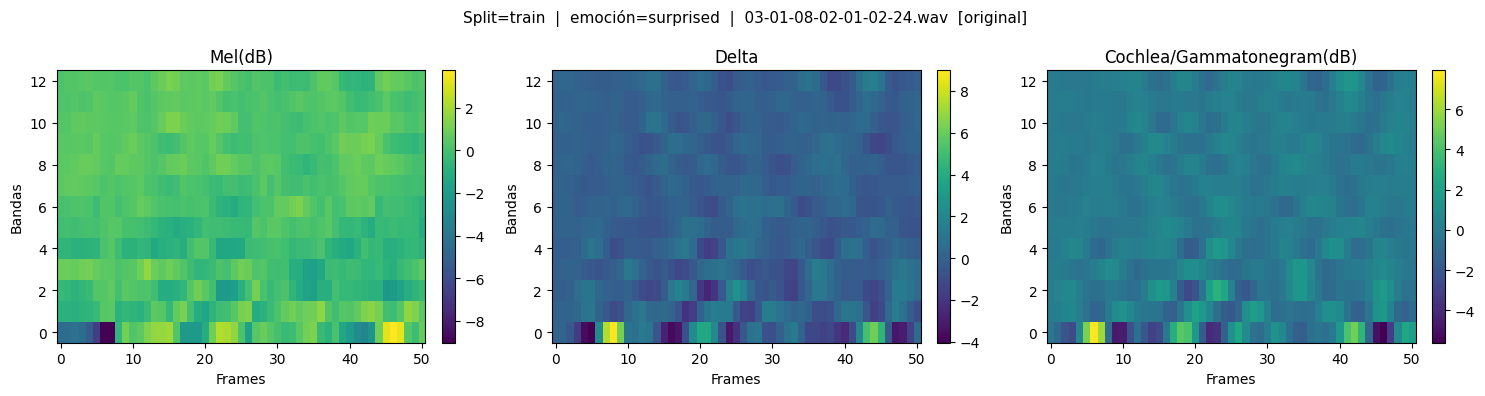

shape=(3, 13, 51)  dtype=torch.float32  label_idx=6


In [47]:
%matplotlib inline

def plot_sample(split='train', idx=None):
    out_path = os.path.join(OUT_DIR_TENSORS, f"{split}_tensors.pt")
    pack = torch.load(out_path, map_location='cpu', weights_only=False)
    x, y, meta = pack['x'], pack['y'], pack['meta']

    if idx is None:
        idx = random.randint(0, len(x) - 1)

    tensor = x[idx]   # [3, N_MELS, TARGET_FRAMES]
    label  = IDX_TO_EMOTION.get(y[idx].item(), '?')
    m      = meta[idx]

    titles = ["Mel(dB)", "Delta", "Cochlea/Gammatonegram(dB)"]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f"Split={split}  |  emoción={label}  |  {m['filename']}  [{m['version']}]", fontsize=11)

    for c in range(3):
        im = axes[c].imshow(tensor[c].numpy(), aspect='auto', origin='lower', cmap='viridis')
        axes[c].set_title(titles[c])
        axes[c].set_xlabel("Frames")
        axes[c].set_ylabel("Bandas")
        plt.colorbar(im, ax=axes[c], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()
    print(f"shape={tuple(tensor.shape)}  dtype={tensor.dtype}  label_idx={y[idx].item()}")

plot_sample('train')

## 12. Copiando tensores a Drive

Copiamos nuestro split de tensores a drive, para importalos en su respectivo *notebook* de entrenamiento


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cp -r {OUT_DIR_TENSORS} /content/drive/MyDrive/